# Exemplo 1: Clustering Hierárquico com Scikit-learn

**Nota**: O método hierárquico aglomerativo segue uma abordagem bottom-up (de baixo para cima), onde:
- Cada ponto começa como um cluster individual;
- A cada iteração, os dois clusters mais próximos são fundidos;
- O processo continua até atingir o número de clusters desejado ou formar um único grande cluster.

In [1]:
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

import pandas as pd

In [2]:
# Carregar dados do conjunto Iris
iris = load_iris()
data = iris.data
labels_true = iris.target

In [6]:
# Criar modelo de clustering hierárquico
# n_clusters: número de grupos a formar
# linkage = 'ward': método de ligação baseado em variância mínima

model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_pred = model.fit_predict(data)

In [7]:
# Comparar com classes reais
pd.crosstab(labels_pred, labels_true)

col_0,0,1,2
row_0,,,
0,0,49,15
1,50,0,0
2,0,1,35


**Explicação**
- AgglomerativeClustering executa um método bottom-up de agrupamento.
- n_clusters = 3: define o número de grupos finais desejados.
- linkage = 'ward?: minimiza a variância total dentro de cada cluster.
- A tabela cruzada ajuda a avaliar visualmente a correspondência entre os clusters e as classes verdadeiras do dataset.

---

# Exemplo 2: K-Means no Irís

**Nota**:

Este exemplo reutiliza os dados carregados no Exemplo 1.

Se estiveres a executar este bloco de forma isolada, certifica-te de que os dados estão carregados com:

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_iris

iris = load_iris()
data = iris.data

In [3]:
# Criar modelo K-Means
# n_clusters: número de clusters desejado
# random_state: controla a aleatoriedade da inicialização

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(data)


In [4]:
# Mostrar centróides
print("Centróides dos clusters:")
print(kmeans.cluster_centers_)

Centróides dos clusters:
[[6.85384615 3.07692308 5.71538462 2.05384615]
 [5.006      3.428      1.462      0.246     ]
 [5.88360656 2.74098361 4.38852459 1.43442623]]


In [5]:
# Avaliar com coeficiente de silhueta
sil_score = silhouette_score(data, labels_kmeans)
print(f"Coeficiente de silhueta: {sil_score:.2f}")

Coeficiente de silhueta: 0.55


**Explicação**:
- n_clusters = 3: especifica o número de grupos.
- fit_predict: ajusta o modelo e obtèm as etiquetas dos clusters.
- clusters_centers_: devolve as coordenadas dos centróides.
- silhouette_score: mede quão bem separados estão os clustes (varia entre -1 e 1)

---

# Exemplo 3: Viasualização com PCA

**Nota**: Este exemplo pressupõe que os dados (data) e os rótulos dos clusters (labels_kmeans) foram gerados preciamente, como no exemplo 2.

In [6]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris = load_iris()
data = iris.data

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(data)


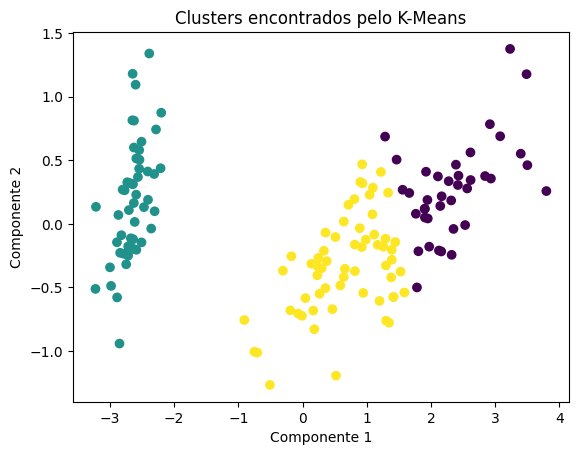

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Redução de dimensionalidade para visualização
pca = PCA(n_components=2)
data_2d = pca.fit_transform(data)

# Visualizar clusters do K_Means
plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels_kmeans, cmap='viridis')
plt.title('Clusters encontrados pelo K-Means')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()

**Explicação**:
- PCA reduz as 4 dimensões do Irís para 2 componentes principais.
- Permite visualizar os agrupamentos de forma mais intuitiva.
As cores representam os clusters encontrados.

---

# Exemplo 4: DBSCAN com Dataset Irís (2 features para visualização)

In [13]:
from sklearn.datasets import load_iris 
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [14]:
# Carregar e preparar os dados 
iris = load_iris()
data = iris.data[:, :2] # Usar apenas 2 features para visualização 
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [15]:
# Aplicar DBSCAN
# eps: raio da vizinhança
# min_samples: número mínimo de pontos para formar um cluster 
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(data_scaled)

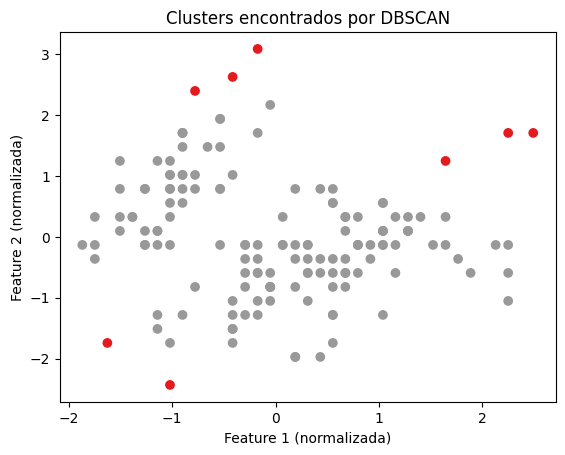

In [16]:
# Visualizar os clusters 
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=labels_db, cmap='Set1') 
plt.title("Clusters encontrados por DBSCAN")
plt.xlabel("Feature 1 (normalizada)")
plt.ylabel("Feature 2 (normalizada)")
plt.show()

In [17]:
# Mostrar etiquetas encontradas
print("Etiquetas encontradas pelo DBSCAN:")
print(set(labels_db))

Etiquetas encontradas pelo DBSCAN:
{np.int64(0), np.int64(-1)}


**Explicação**:
`eps` controla o raio de vizinhança e `min_samples` o mínimo de pontos para formar uma região densa. O rótulo `-1`indica pontos classificafos como ruído. 

---

# Exemplo 5: Gaussian Mixture Model (GMM) no Dataset Iris

In [18]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from sklearn.datasets import load_iris

In [19]:
# Carregar dados 
iris = load_iris()
X = iris.data
true_labels = iris.target 

In [20]:
# Ajustar modelo GMM 
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)
pred_labels = gmm.predict(X)

In [21]:
# Avaliação com índice Rand ajustado 
ari = adjusted_rand_score(true_labels, pred_labels)
print(f"Adjusted Rand Index (ARI): {ari:.2f}")

Adjusted Rand Index (ARI): 0.90


**Explicação**: O GMM modela clusters como distribuições normais. O `ARI` avalia a sobreposição entre os clusters encontrados e as classes reais.

---

# Exemplo 6: Explorar DBSCAN com diferentes valores de eps

In [22]:
from sklearn.datasets import load_iris 
from sklearn.cluster import DBSCAN 
from sklearn.preprocessing import StandardScaler

In [23]:
# Carregar e preparar os dados
iris = load_iris() 
data = iris.data[:, :2] # Usar apenas duas features 
scaler = StandardScaler() 
data_scaled = scaler.fit_transform(data)

In [24]:
# Testar diferentes valores de eps
for eps_val in [0.3, 0.5, 0.7]:
    dbsacn = DBSCAN(eps=eps_val, min_samples=5)
    labels = dbsacn.fit_predict(data_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps_val}: clusters encontrados = {n_clusters}")

eps=0.3: clusters encontrados = 2
eps=0.5: clusters encontrados = 1
eps=0.7: clusters encontrados = 1


**Explicação**:
- eps define o raio da vizinhança local para cada ponto.
- min_samples=5: mínimo de pontos para formar um cluster denso.
- O número de clusters encontrados muda com eps, afetando a sensibilidade a ruído e a separação de grupos.

---

# Exemplo 7: GMM aplicado a dados sintéticos

In [25]:
from sklearn.datasets import make_blobs 
from sklearn.mixture import GaussianMixture 

import matplotlib.pyplot as plt

In [26]:
# Gerar dados sintéticos gaussianos

X_synth, y_synth = make_blobs(
    n_samples=300, # número total de amostras 
    centers=3, # número de clusters 
    cluster_std=0.60, # dispersão dos clusters 
    random_state=42 # reprodutibilidade 
)

In [27]:
# Criar e ajustar modelo GMM
gmm_synth = GaussianMixture(n_components=3, random_state=42) 
gmm_synth.fit(X_synth)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [28]:
# Obter previsões dos clusters 
y_pred = gmm_synth.predict(X_synth)

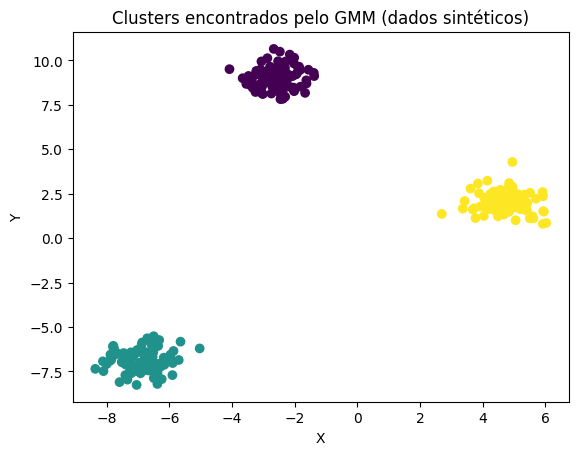

In [29]:
# Visualizar resultados 
plt.scatter(X_synth[:, 0], X_synth[:, 1], c=y_pred, cmap='viridis')
plt.title("Clusters encontrados pelo GMM (dados sintéticos)") 
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**Explicação**: Este exemplo mostra como o GMM consegue identificar clusters com forma e densidade semelhantes às gaussianas, sendo ideal para dados com estas características.

NOTA: Dados sintéticos são conjuntos de dados artificiais, ou seja, gerados manualmente ou por algoritmos, em vez de serem recolhidos do mundo real. São amplamente utilizados para fins de:
- Teste e desenvolvimento de algoritmos;
- Simulação de cenários controlados;
- Validação de modelos em ambiente seguro e previsível.

Por que usar dados sintéticos?
1. Permitem controlar totalmente a estrutura dos dados (ex.: número de clusters, dispersão, dimensões).
1. Facilitam a visualização e compreensão de algoritmos de aprendizagem.
1. Evita problemas legais ou de privacidade, já que não envolvem dados reais de pessoas.


---